<a href="https://www.kaggle.com/code/amirhjandaghian/analysis-a-b-test-landing-page-maven-analytics?scriptVersionId=311040389" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Analysis Pipline

## 0. impoart libaries


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter

import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

dir_path = Path.cwd()

In [15]:
# Helper function 
def inspect_data(dataframe):
    df = dataframe.copy()

    print("shape of df:", df.shape)
    print('-'*25)

    # null
    null_counts = df.isna().sum().rename("null_count").to_frame()
    print("Null value counts:")
    print(null_counts[null_counts['null_count'] > 0].to_string() if not null_counts[null_counts['null_count'] > 0].empty else "No null values found.")
    print('-'*25)

    # duplicates
    duplicate_count = df.duplicated().sum()
    print(f"Number of duplicate rows: {duplicate_count}")
    print('-'*25)

    # data types
    print("Data types of each column:")
    print(df.dtypes)
    print('-'*25)

    # summary statistics
    print("Summary statistics for numeric columns:")
    # print(df.describe().to_string())

    print(df.describe(include='number').T.to_string())
    print()
    print(df.describe(include='object').T.to_string())
    print('-'*25)

    # head
    print("First 5 rows of the dataframe:")
    print(df.head().to_string(index=False))


## 1. Load the data

In [16]:
ab_test_data = pd.read_parquet(dir_path / 'data/processed' / 'session_pageviews_ab_test.parquet')

# inspect_data(ab_test_data)
ab_test_data.head()

,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer,first_pageview_url,last_pageview_url,concated_urls,pageview_count,first_pageview_time,last_pageview_time
0,11683,2012-06-19 00:35:54,10936,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,/lander-1,None,/lander-1,1,2012-06-19 00:35:54,2012-06-19 00:35:54
1,11684,2012-06-19 00:48:25,10937,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,/home,None,/home,1,2012-06-19 00:48:25,2012-06-19 00:48:25
2,11685,2012-06-19 01:02:38,10938,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,/lander-1,None,/lander-1,1,2012-06-19 01:02:38,2012-06-19 01:02:38
3,11686,2012-06-19 01:31:57,10939,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,/lander-1,/products,/lander-1 -> /products,2,2012-06-19 01:31:57,2012-06-19 01:32:51
4,11687,2012-06-19 01:36:39,10940,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,/home,None,/home,1,2012-06-19 01:36:39,2012-06-19 01:36:39


## 2. EDA

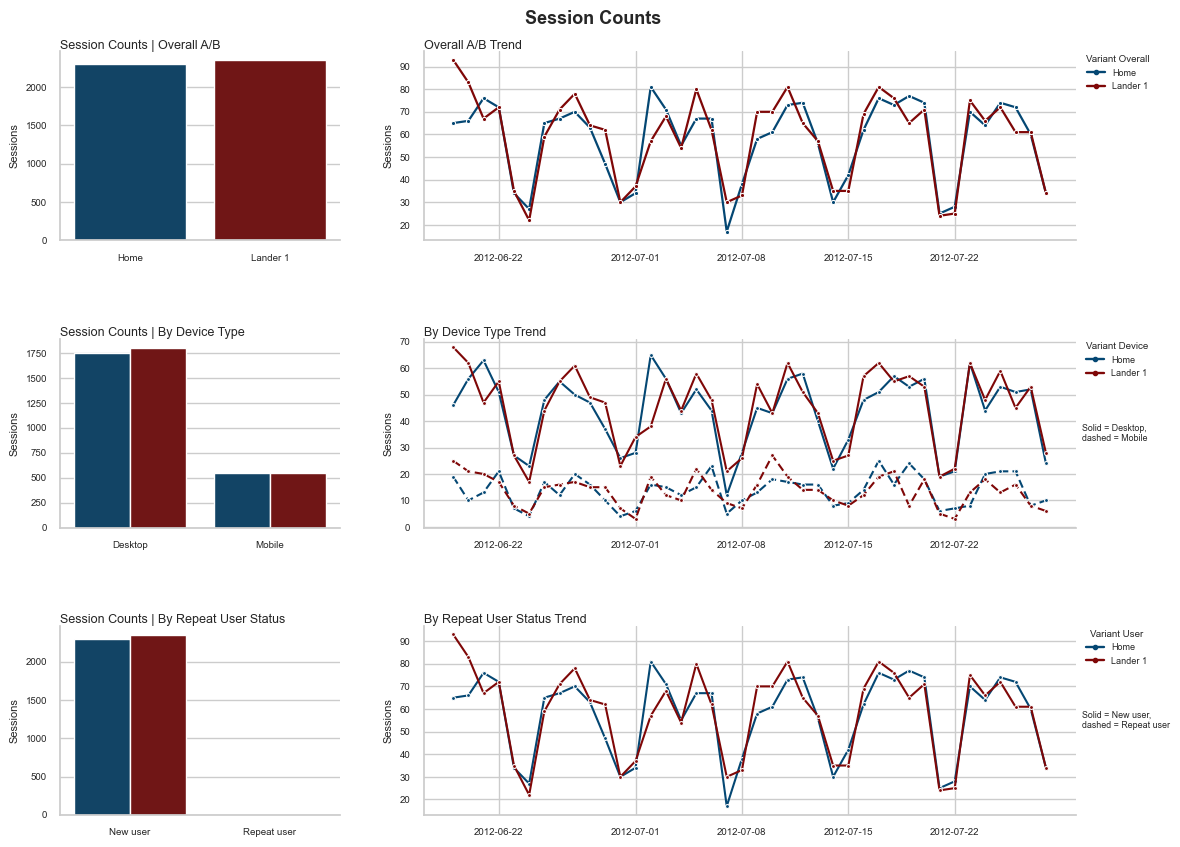

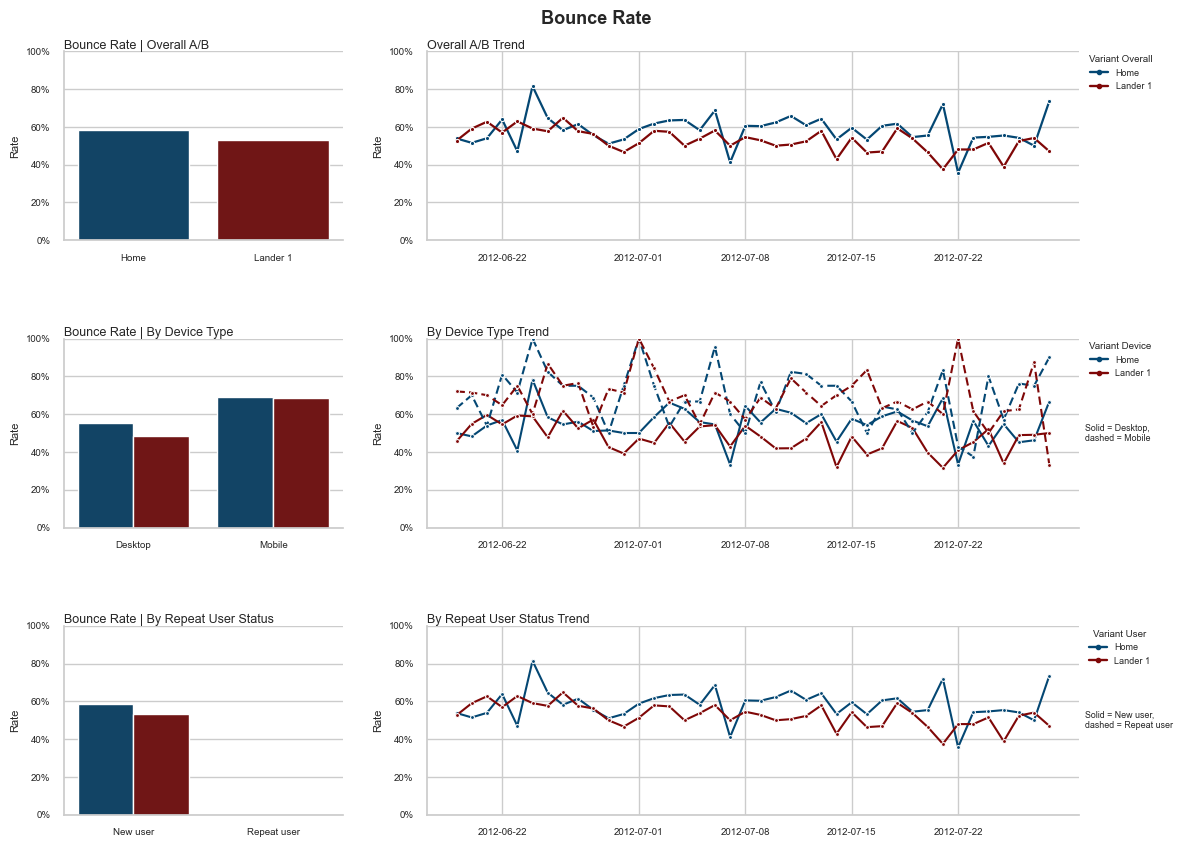

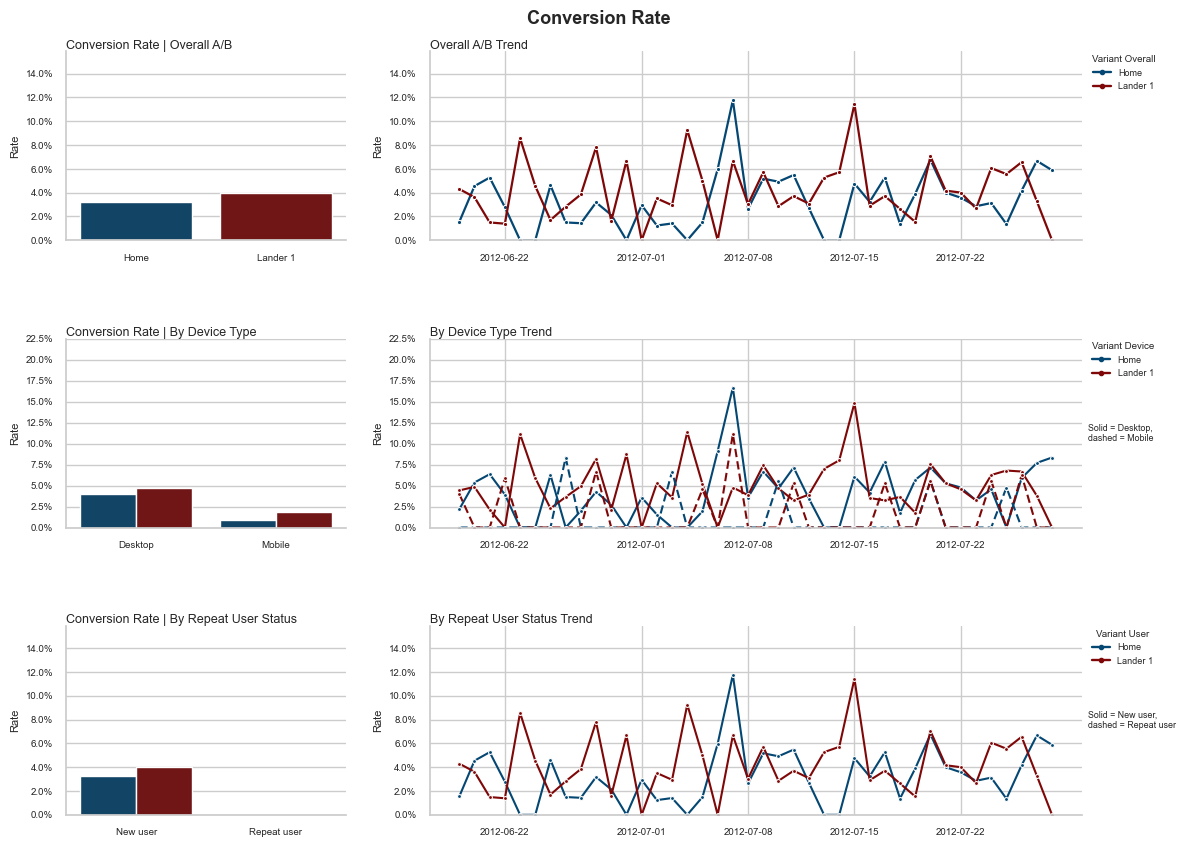

In [17]:
sns.set_theme(style="whitegrid", font_scale=0.9)

variant_display_map = {
    "/home": "Home",
    "/lander-1": "Lander 1",
}
color_map = {
    '/home': "#044773",
    '/lander-1': "#7f0707"
}

variant_palette = {variant_display_map[key]: value for key, value in color_map.items()}
variant_order = [variant_display_map[key] for key in color_map.keys()]
device_display_map = {"desktop": "Desktop", "mobile": "Mobile"}
repeat_display_map = {0: "New user", 1: "Repeat user"}

eda_data = ab_test_data.copy()
eda_data["date"] = eda_data["created_at"].dt.normalize()
eda_data["variant_display"] = eda_data["first_pageview_url"].map(variant_display_map)
eda_data["device_display"] = eda_data["device_type"].map(device_display_map)
eda_data["repeat_display"] = eda_data["is_repeat_session"].map(repeat_display_map)
eda_data["session_weight"] = 1
eda_data["is_bounced"] = eda_data["pageview_count"].eq(1).astype("int8")

if "is_converted" not in eda_data.columns:
    eda_data["is_converted"] = (
        eda_data["concated_urls"].str.contains("thank", case=False, na=False)
        | eda_data["last_pageview_url"].fillna("").str.contains("thank|order", case=False, regex=True)
    ).astype("int8")

segment_specs = [
    {
        "title": "Overall A/B",
        "segment_col": None,
        "segment_label": None,
        "segment_order": None,
        "legend_title": "Variant Overall",
        "line_styles": None,
        "style_note": None,
    },
    {
        "title": "By Device Type",
        "segment_col": "device_display",
        "segment_label": "device_display",
        "segment_order": [device_display_map["desktop"], device_display_map["mobile"]],
        "legend_title": "Variant Device",
        "line_styles": {
            device_display_map["desktop"]: "-",
            device_display_map["mobile"]: (0, (4, 2)),
        },
        "style_note": "Solid = Desktop, \ndashed = Mobile",
    },
    {
        "title": "By Repeat User Status",
        "segment_col": "repeat_display",
        "segment_label": "repeat_display",
        "segment_order": [repeat_display_map[0], repeat_display_map[1]],
        "legend_title": "Variant User",
        "line_styles": {
            repeat_display_map[0]: "-",
            repeat_display_map[1]: (0, (4, 2)),
        },
        "style_note": "Solid = New user, \ndashed = Repeat user",
    },
]


def _finalize_axis(axis, y_label, is_rate=False, rate_upper=None):
    axis.set_xlabel("")
    axis.set_ylabel(y_label, fontsize=8)
    axis.tick_params(axis="both", labelsize=7)
    if is_rate:
        axis.set_ylim(0, rate_upper if rate_upper is not None else 1)
        axis.yaxis.set_major_formatter(PercentFormatter(1.0))
    sns.despine(ax=axis)


def plot_metric_dashboard(dataframe, metric_col, metric_title, y_label, is_rate=False, dynamic_rate_scale=False):
    fig, axes = plt.subplots(
        3,
        2,
        figsize=(14.2, 9.2),
        gridspec_kw={"width_ratios": [3, 7], "wspace": 0.18, "hspace": 0.52},
        constrained_layout=False,
    )
    fig.suptitle(metric_title, fontsize=13, fontweight="bold", y=0.985)
    fig.subplots_adjust(right=0.84, top=0.94)

    for row_idx, spec in enumerate(segment_specs):
        bar_ax = axes[row_idx, 0]
        trend_ax = axes[row_idx, 1]
        aggfunc = "sum" if metric_col == "session_weight" else "mean"

        if spec["segment_col"] is None:
            bar_df = (
                dataframe.groupby("variant_display", as_index=False)
                .agg(metric=(metric_col, aggfunc))
                .sort_values("variant_display")
            )
            trend_df = (
                dataframe.groupby(["date", "variant_display"], as_index=False)
                .agg(metric=(metric_col, aggfunc))
                .sort_values(["date", "variant_display"])
            )

            sns.barplot(
                data=bar_df,
                x="variant_display",
                y="metric",
                order=variant_order,
                palette=variant_palette,
                ax=bar_ax,
                errorbar=None,
            )
            sns.lineplot(
                data=trend_df,
                x="date",
                y="metric",
                hue="variant_display",
                hue_order=variant_order,
                palette=variant_palette,
                marker="o",
                linewidth=1.6,
                markersize=3,
                ax=trend_ax,
                legend=False,
            )
        else:
            bar_df = (
                dataframe.groupby([spec["segment_label"], "variant_display"], as_index=False)
                .agg(metric=(metric_col, aggfunc))
                .sort_values([spec["segment_label"], "variant_display"])
            )
            trend_df = (
                dataframe.groupby(["date", "variant_display", spec["segment_label"]], as_index=False)
                .agg(metric=(metric_col, aggfunc))
                .sort_values(["date", spec["segment_label"], "variant_display"])
            )

            sns.barplot(
                data=bar_df,
                x=spec["segment_label"],
                y="metric",
                hue="variant_display",
                order=spec["segment_order"],
                hue_order=variant_order,
                palette=variant_palette,
                ax=bar_ax,
                errorbar=None,
            )

            for segment_value in spec["segment_order"]:
                segment_trend_df = trend_df[trend_df[spec["segment_label"]] == segment_value]
                sns.lineplot(
                    data=segment_trend_df,
                    x="date",
                    y="metric",
                    hue="variant_display",
                    hue_order=variant_order,
                    palette=variant_palette,
                    marker="o",
                    linewidth=1.5,
                    markersize=2.8,
                    linestyle=spec["line_styles"][segment_value],
                    ax=trend_ax,
                    legend=False,
                )

        rate_upper = None
        if is_rate and dynamic_rate_scale:
            combined_max = max(float(bar_df["metric"].max()), float(trend_df["metric"].max()))
            rate_upper = max(0.06, combined_max * 1.35)

        _finalize_axis(bar_ax, y_label, is_rate=is_rate, rate_upper=rate_upper)
        _finalize_axis(trend_ax, y_label, is_rate=is_rate, rate_upper=rate_upper)
        bar_ax.set_title(f"{metric_title} | {spec['title']}", fontsize=9, loc="left", pad=2)
        trend_ax.set_title(f"{spec['title']} Trend", fontsize=9, loc="left", pad=2)
        trend_ax.tick_params(axis="x", rotation=0)

        if bar_ax.get_legend() is not None:
            bar_ax.get_legend().remove()

        legend_handles = [
            Line2D([0], [0], color=variant_palette[label], lw=1.7, marker="o", markersize=3, label=label)
            for label in variant_order
        ]
        trend_ax.legend(
            handles=legend_handles,
            title=spec["legend_title"],
            loc="upper left",
            bbox_to_anchor=(1.01, 1.0),
            fontsize=6.5,
            title_fontsize=7,
            frameon=False,
            borderaxespad=0.0,
        )

        if spec["style_note"] is not None:
            trend_ax.text(
                1.01,
                0.55,
                spec["style_note"],
                transform=trend_ax.transAxes,
                fontsize=6.4,
                va="top",
                ha="left",
            )

    plt.show()


plot_metric_dashboard(eda_data, "session_weight", "Session Counts", "Sessions", is_rate=False)
plot_metric_dashboard(eda_data, "is_bounced", "Bounce Rate", "Rate", is_rate=True)
plot_metric_dashboard(eda_data, "is_converted", "Conversion Rate", "Rate", is_rate=True, dynamic_rate_scale=True)

## 3. Data Quality & Validity Checks

**Data Leakage:**
making sure about randomization unit and data leakage

In [18]:
control_set = set(ab_test_data[ab_test_data['first_pageview_url'] == '/home']['user_id'])
treatment_set = set(ab_test_data[ab_test_data['first_pageview_url'] == '/lander-1']['user_id'])


overlap = control_set & treatment_set
if overlap:
    raise ValueError(f"Danger! {len(overlap)} users are in both groups.")

print("No overlap detected. Randomization unit is user_id.")

No overlap detected. Randomization unit is user_id.


**Sample Ratio Missmatch:**

In [19]:
srm_info = (
            ab_test_data.groupby('first_pageview_url').agg(count=('website_session_id', 'size'))
            .assign(percentage=lambda x: (x['count'] / x['count'].sum() * 100).round(5))
            .reset_index()
            )

print(srm_info.to_string())

  first_pageview_url  count  percentage
0              /home   2295    49.40797
1          /lander-1   2350    50.59203


In [20]:
from scipy.stats import chisquare

result = chisquare(
                f_obs=srm_info['count'].values, 
                f_exp=srm_info['count'].values.sum()/2
                )
print(f"Chi-square statistic: {result.statistic:.4f}")
print(f"P-value: {result.pvalue:.4f}")

Chi-square statistic: 0.6512
P-value: 0.4197


There is no significant difference between the observed and expected session counts, suggesting that there is no sample ratio mismatch in the data.

- **Experiment validity is confirmed**: no user-level crossover between control and treatment, so randomization integrity is intact.
- **Traffic split is balanced**: assignment appears consistent with the intended experiment design.
- **No novelty or timing bias detected**: treatment and control follow stable, comparable trends across the test period.
- **Device mix is not a confounder**: desktop/mobile composition differences reflect normal traffic, not experimental bias.
- ✅ **Conclusion**: data quality checks passed, and the A/B test results are reliable for decision-making.


## 4. Metric Calculations

### **Bounce Rate**

In [21]:
# Bounce = single-page session
ab_test_data['is_bounced'] = ab_test_data['pageview_count'].eq(1).astype('int8')

bounce_rate = (ab_test_data
                .groupby(['user_id']).agg(bounce_rate=('is_bounced', 'mean')).reset_index()
                    .groupby(ab_test_data['first_pageview_url']).agg(avg_bounce_rate=('bounce_rate', 'mean'),
                                                                        bounce_cases=('bounce_rate', 'sum'),
                                                                        total_observations=('bounce_rate', 'count')
                                                                        ).reset_index()
                )

print(bounce_rate.to_string(index=False))

first_pageview_url  avg_bounce_rate  bounce_cases  total_observations
             /home         0.585621        1344.0                2295
         /lander-1         0.531489        1249.0                2350


---
### **Conversion Rate**

In [22]:
ab_test_data['is_converted'] = ab_test_data['last_pageview_url'].eq('/thank-you-for-your-order').astype('int8')

conversion_rate = (ab_test_data
                    .groupby(['user_id']).agg(conversion_rate=('is_converted', 'mean')).reset_index()
                        .groupby(ab_test_data['first_pageview_url']).agg(avg_conversion_rate=('conversion_rate', 'mean'),
                                                                        conversion_cases=('conversion_rate', 'sum'),
                                                                        total_observations=('conversion_rate', 'count')
                                                                        ).reset_index()
                )

print(conversion_rate.to_string(index=False))

first_pageview_url  avg_conversion_rate  conversion_cases  total_observations
             /home             0.032244              74.0                2295
         /lander-1             0.040000              94.0                2350


---
### **Average Order Value**

In [23]:
# we need order value from ORDERS
orders = pd.read_csv(dir_path / 'data/orders.csv')

# adding value to the main df.
ab_test_data = ab_test_data.merge(orders.loc[:, ['website_session_id', 'price_usd']],
                                        how='left')

# AOV calculation

aov = (ab_test_data
        .groupby(['user_id']).agg(aov_user=('price_usd', 'mean')).reset_index()
                .groupby(ab_test_data['first_pageview_url']).agg(
                                                                avg_aov = ('aov_user', 'mean'),
                                                                total_observations = ('aov_user', 'count'),
                                                                variance = ('aov_user', 'var')
                                                                ).reset_index()
)

print(aov.to_string(index=False))

aov_data = pd.pivot_table(
                ab_test_data,
                values='price_usd',
                columns='first_pageview_url',
                index='user_id'
        )

first_pageview_url  avg_aov  total_observations  variance
             /home    49.99                  74       0.0
         /lander-1    49.99                  94       0.0


## 5. Statistical Testing


In [24]:
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind, t

# == bounce rate ===
stat, pval = proportions_ztest(
    count=bounce_rate['bounce_cases'].values,
    nobs=bounce_rate['total_observations'].values,
    alternative="two-sided"  # two-side
)

print(f"Bounce Rate Z-stat: {stat:.4f}, P-value: {pval:.4f}")
print('We reject the null hypothesis if the p-value is less than 0.05.' if pval < 0.05 else 'We fail to reject the null hypothesis.')
print('-' * 50)

# == converstion rate == 
stat, pval = proportions_ztest(
    count=conversion_rate['conversion_cases'].values,
    nobs=conversion_rate['total_observations'].values,
    alternative="two-sided"  # we want conversion to DROP
)

print(f"Conversion Rate Z-stat: {stat:.4f}, P-value: {pval:.4f}")
print('We reject the null hypothesis if the p-value is less than 0.05.' if pval < 0.05 else 'We fail to reject the null hypothesis.')
print('-' * 50)

# == AOV == 
aov_control = aov_data['/home'].dropna().values.round(2)
aov_treatment = aov_data['/lander-1'].dropna().values.round(2)

if np.isclose(np.var(aov_control), 0) and np.isclose(np.var(aov_treatment), 0):
    print("AOV T-stat:No variance → no meaningful test")

else:       
    stat, pval = ttest_ind(
        aov_control, 
        aov_treatment, 
        equal_var=False)

    print(f"AOV T-stat: {stat:.4f}, P-value: {pval:.4f}")
    print('We reject the null hypothesis if the p-value is less than 0.05.' if pval < 0.05 else 'We fail to reject the null hypothesis.')

Bounce Rate Z-stat: 3.7143, P-value: 0.0002
We reject the null hypothesis if the p-value is less than 0.05.
--------------------------------------------------
Conversion Rate Z-stat: -1.4155, P-value: 0.1569
We fail to reject the null hypothesis.
--------------------------------------------------
AOV T-stat:No variance → no meaningful test


## 6. Practical Significance & Confidence Intervals


In [25]:
from scipy.stats import norm

alpha = 0.05

# Absolute CI (control - treatment → positive = improvement)
def proportion_ci(p_control, n_control, p_treatment, n_treatment, alpha=0.05):
    diff = p_control - p_treatment
    se   = np.sqrt(
        p_control * (1 - p_control) / n_control +
        p_treatment * (1 - p_treatment) / n_treatment
    )
    z = norm.ppf(1 - alpha / 2)
    return (diff - z * se, diff + z * se)


# Relative CI (relative to control)
def proportion_ci_relative(p_control, n_control, p_treatment, n_treatment, alpha=0.05):
    ci_abs = proportion_ci(p_control, n_control, p_treatment, n_treatment, alpha)
    return (ci_abs[0] / p_control, ci_abs[1] / p_control)


# ===================== Data =====================

control_url = "/home"
treatment_url = "/lander-1"

p_control = bounce_rate.loc[
    bounce_rate["first_pageview_url"].eq(control_url),
    "avg_bounce_rate"
].iloc[0]

n_control = int(bounce_rate.loc[
    bounce_rate["first_pageview_url"].eq(control_url),
    "total_observations"
].iloc[0])

p_treatment = bounce_rate.loc[
    bounce_rate["first_pageview_url"].eq(treatment_url),
    "avg_bounce_rate"
].iloc[0]

n_treatment = int(bounce_rate.loc[
    bounce_rate["first_pageview_url"].eq(treatment_url),
    "total_observations"
].iloc[0])


# ===================== CI =====================

br_ci = proportion_ci(p_control, n_control, p_treatment, n_treatment, alpha)
br_ci_rel = proportion_ci_relative(p_control, n_control, p_treatment, n_treatment, alpha)


# ===================== Output =====================

print(f"Bounce Rate Improvement (control - treatment) CI: ({br_ci[0]:.4f}, {br_ci[1]:.4f})")
print(f"Lift: {(p_control - p_treatment) / p_control:.2%}, Relative Improvement CI: ({br_ci_rel[0]:.2%}, {br_ci_rel[1]:.2%})")

Bounce Rate Improvement (control - treatment) CI: (0.0256, 0.0826)
Lift: 9.24%, Relative Improvement CI: (4.37%, 14.11%)


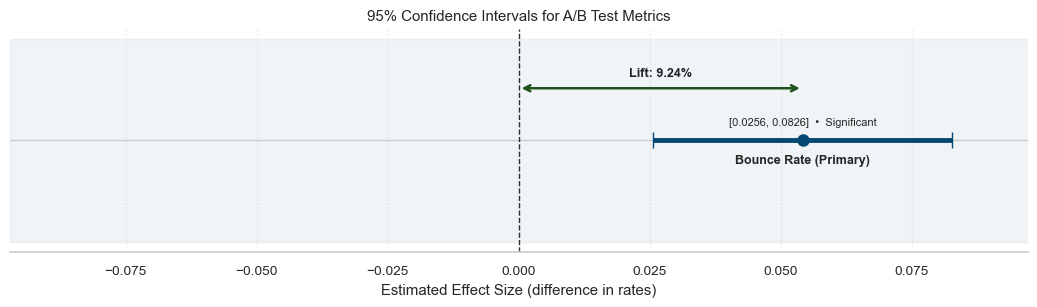

In [26]:
# ===================== CI chart =====================
# Point estimates (keep directions consistent with your CI definitions)
br_diff = (
    bounce_rate.loc[bounce_rate["first_pageview_url"].eq("/home"), "avg_bounce_rate"].iloc[0]
    - bounce_rate.loc[bounce_rate["first_pageview_url"].eq("/lander-1"), "avg_bounce_rate"].iloc[0]
)  # control - treatment

metrics = [
    {"name": "Bounce Rate (Primary)", "diff": br_diff, "ci": br_ci, "color": "#044773", "lw": 3.5, "ms": 8},
]

fig, ax = plt.subplots(figsize=(10.5, 3.2))
ypos = np.arange(len(metrics))[::-1]  # primary metric on top

for y, m in zip(ypos, metrics):
    low, high = m["ci"]
    diff = m["diff"]
    xerr = np.array([[diff - low], [high - diff]])  # asymmetric error bars

    ax.errorbar(
        x=diff, y=y, xerr=xerr,
        fmt='o', color=m["color"], ecolor=m["color"],
        elinewidth=m["lw"], capsize=6, markersize=m["ms"], zorder=3
    )

    sig = "Significant" if (low > 0) or (high < 0) else "Not significant"
    ax.text(br_diff, y+0.051, f"[{low:.4f}, {high:.4f}]  •  {sig}", ha="center", fontsize=8)
    ax.text(br_diff, y - 0.08, m["name"], fontsize=9, ha="center", fontweight="bold")

# Reference line at zero effect
ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.8)

# Subtle emphasis band for primary metric row
ax.axhspan(ypos[0] - 0.35, ypos[0] + 0.35, color="#044773", alpha=0.06, zorder=0)

all_bounds = [br_ci[0], br_ci[1], 0]
pad = (max(all_bounds) - min(all_bounds)) * 0.15 + 0.002
ax.set_xlim(-max(all_bounds) - pad, max(all_bounds) + pad)
# Lift arrow (from no-effect to observed effect), drawn above the CI
y_arrow = ypos[0] + 0.18
lift_pct = br_diff / p_control

ax.annotate(
    "",
    xy=(0, y_arrow),
    xytext=(br_diff, y_arrow),
    arrowprops=dict(arrowstyle="<->", color="#1E5419", lw=1.8),
    zorder=4
)

ax.text(
    br_diff / 2,
    y_arrow + 0.03,
    f"Lift: {lift_pct:.2%}",
    ha="center",
    va="bottom",
    fontsize=9,
    fontweight="bold",
    color="#222222"
)
ax.set_yticks(ypos)
ax.set_yticklabels('')
ax.set_xlabel("Estimated Effect Size (difference in rates)")
ax.set_title("95% Confidence Intervals for A/B Test Metrics")
ax.grid(axis="x", linestyle=":", alpha=0.45)
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.show()

## 7. Breakdown Analysis

Only `device_type` is a relavant variable in our dataset and experiment.

In [27]:
# average bounce rate per user broken down by device type and experiment
br_break_down = (
    ab_test_data
        .groupby(['first_pageview_url', 'device_type', 'user_id'], as_index=False)
            .agg(bounce_rate=('is_bounced', 'mean'))
                .groupby(['first_pageview_url', 'device_type'], as_index=False)
                    .agg(
                        avg_bounce_rate=('bounce_rate', 'mean'),
                        bounce_cases=('bounce_rate', 'sum'),
                        total_observations=('bounce_rate', 'count')
                    )
)


print(br_break_down.to_string(index=False))
print('='*100)

# === test === 

# === alpha correction for multiple tests ===
#  2 tests (mobile vs desktop)

alpha = 0.05
num_tests = 2
adjusted_alpha = alpha / num_tests
print(f"Bonferroni-corrected alpha for {num_tests} tests: {adjusted_alpha:.4f}")
print('='*100)

# run proportion z-test by device type
devices = ["mobile", "desktop"]
rows = []

for device in devices:
    seg = br_break_down[br_break_down["device_type"].eq(device)]

    control = seg[seg["first_pageview_url"].eq("/home")].iloc[0]
    treatment = seg[seg["first_pageview_url"].eq("/lander-1")].iloc[0]

    stat, pval = proportions_ztest(
        count=[control["bounce_cases"], treatment["bounce_cases"]],
        nobs=[control["total_observations"], treatment["total_observations"]],
        alternative="two-sided"
    )

    rows.append({
        "test": device,
        "stat": stat,
        "pval": pval,
        'diff_ctrl-trtmnt': control["avg_bounce_rate"] - treatment["avg_bounce_rate"],
        'ci_low': proportion_ci(
            control["avg_bounce_rate"], control["total_observations"],
            treatment["avg_bounce_rate"], treatment["total_observations"],
            alpha=adjusted_alpha
        )[0],
        'ci_high': proportion_ci(
            control["avg_bounce_rate"], control["total_observations"],
            treatment["avg_bounce_rate"], treatment["total_observations"],
            alpha=adjusted_alpha
        )[1],
    })

br_break_down_test = pd.DataFrame(rows)

print(br_break_down_test.round(4).to_string(col_space=10))

first_pageview_url device_type  avg_bounce_rate  bounce_cases  total_observations
             /home     desktop         0.551862         963.0                1745
             /home      mobile         0.692727         381.0                 550
         /lander-1     desktop         0.485319         876.0                1805
         /lander-1      mobile         0.684404         373.0                 545
Bonferroni-corrected alpha for 2 tests: 0.0250
                 test       stat       pval  diff_ctrl-trtmnt     ci_low    ci_high
0              mobile     0.2974     0.7662            0.0083    -0.0544     0.0711
1             desktop     3.9668     0.0001            0.0665     0.0290     0.1041


# Final Recommendation


✅ **Ship the new landing page to all users immediately.**

  -> **suggested a dedicated mobile UX test for improvement in mobile bounce rate.**